## <center>Clustering Diamonds<center>

Business Problem

Clustering is an unsupervised learning technique used to group similar data points.

In this project, we aim to cluster diamonds (or any dataset with physical attributes) based on features such as carat, cut, color, depth, table, and price.

Objectives:

Identify natural groupings in the data without using labels.

Understand the characteristics of each cluster.

Evaluate clusters with metrics like elbow method, silhouette score, and DBSCAN.

Interpret and name the clusters for business insights (e.g., “High-value large diamonds,” “Small budget diamonds”).

Applications:

Customer segmentation in retail

Inventory classification for online marketplaces

Pricing and marketing strategies based on feature patterns


##### Data Preprocessing

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("gemstone.csv")

features = ['carat','depth','table','price','x','y','z']
X = df[features]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### K-Means Clustering
##### Determine Optimal K (Elbow Method & Silhouette Score)

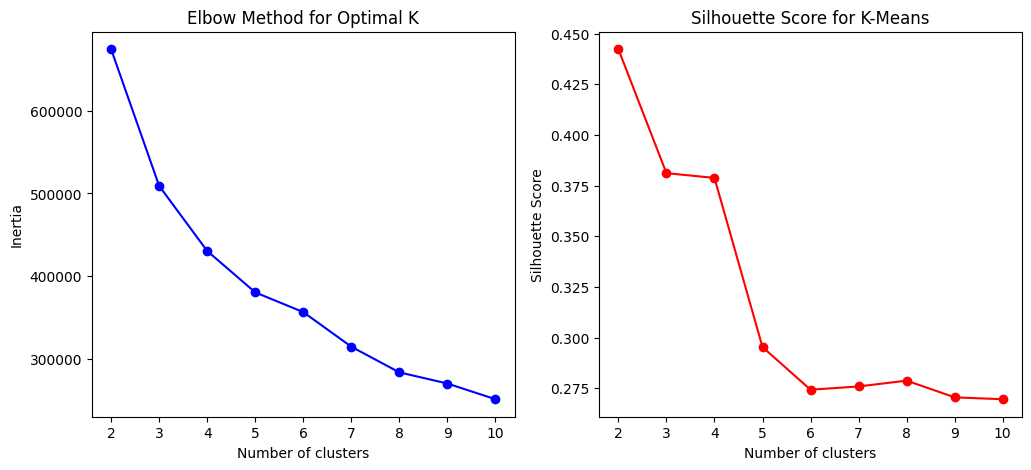

In [5]:
from sklearn.utils import resample
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Sample 2000 points for silhouette calculation
X_sample = resample(X_scaled, n_samples=10000, random_state=42)

inertia = []
sil_scores = []

K_range = range(2,11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    
    # silhouette on sample only
    sil = silhouette_score(X_sample, kmeans.predict(X_sample))
    sil_scores.append(sil)

# Elbow method
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(K_range, inertia, 'bo-')
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
# Silhouette score
plt.subplot(1,2,2)
plt.plot(K_range, sil_scores, 'ro-')
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for K-Means")
plt.show()



##### Fit K-Means with Selected K

In [31]:
# Sample 10000 points for silhouette calculation
optimal_k = 3  # Example
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = kmeans_labels



##### MeanShift Clustering

In [32]:
from sklearn.cluster import MeanShift
from sklearn.utils import resample

# Sample 2000 points
X_sample = resample(X_scaled, n_samples=2000, random_state=42)

ms = MeanShift()
ms_labels = ms.fit_predict(X_sample)

print("Number of clusters detected:", len(set(ms_labels)))

Number of clusters detected: 3


##### Agglomerative Clustering

In [33]:
from sklearn.utils import resample
from sklearn.cluster import AgglomerativeClustering 
# Sample 10000 points
X_sample = resample(X_scaled, n_samples=10000, random_state=42)
agglo = AgglomerativeClustering(n_clusters=optimal_k)
agg_labels = agglo.fit_predict(X_sample)

# Create a new dataframe for the sample
df_sample = df.sample(n=10000, random_state=42).copy()
df_sample['Agglomerative_Cluster'] = agg_labels

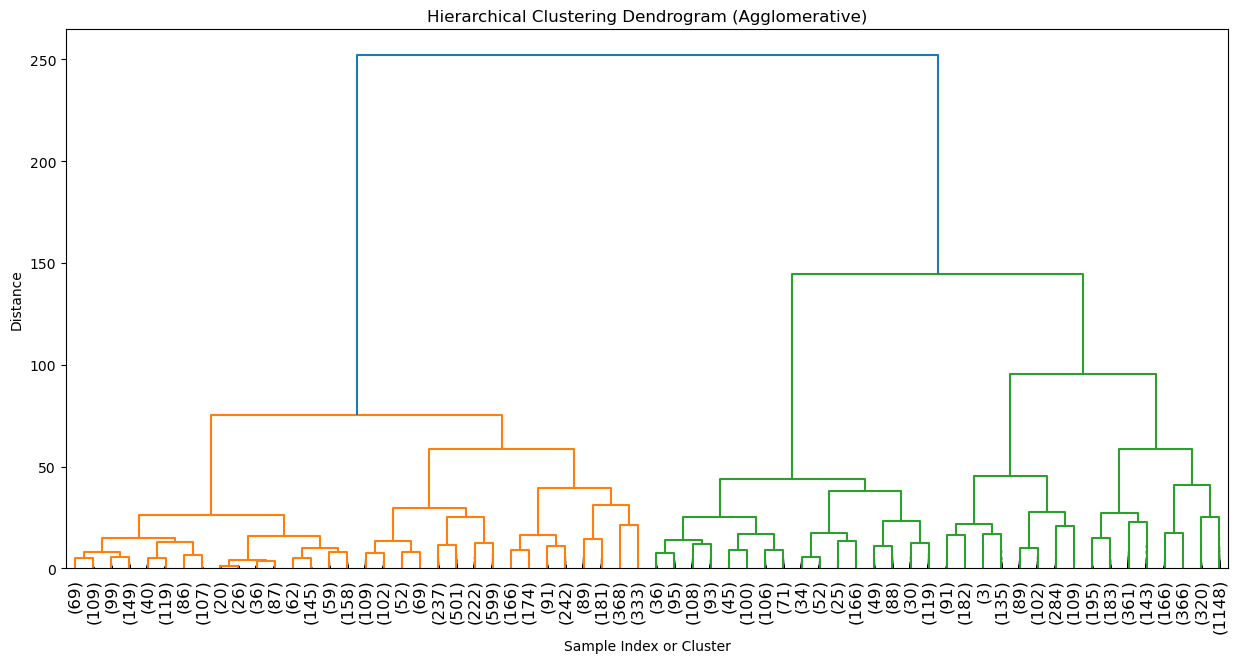

In [34]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
from sklearn.utils import resample

# Sample 2000 points for fast dendrogram
X_sample = resample(X_scaled, n_samples=10000, random_state=42)

# Compute linkage matrix using 'ward' method
Z = linkage(X_sample, method='ward')

plt.figure(figsize=(15, 7))
dendrogram(
    Z,
    truncate_mode='level',  # show only top levels
    p=5,  # number of levels to show
    leaf_rotation=90.,
    leaf_font_size=12.,
    show_contracted=True
)
plt.title("Hierarchical Clustering Dendrogram (Agglomerative)")
plt.xlabel("Sample Index or Cluster")
plt.ylabel("Distance")
plt.show()

#### Cluster Distribution Plot

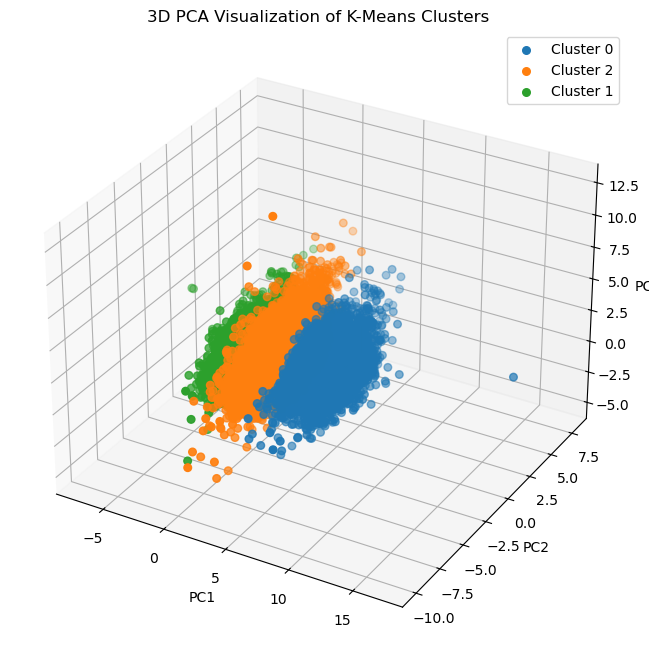

In [39]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # for 3D plot
import seaborn as sns
# Reduce to 3 principal components
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Optional: store in a dataframe for easy plotting
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])
df_pca['KMeans_Cluster'] = df['KMeans_Cluster']  # Add cluster labels
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

clusters = df_pca['KMeans_Cluster'].unique()
colors = sns.color_palette("tab10", len(clusters))

for i, c in enumerate(clusters):
    subset = df_pca[df_pca['KMeans_Cluster'] == c]
    ax.scatter(subset['PC1'], subset['PC2'], subset['PC3'], 
               label=f'Cluster {c}', s=30, color=colors[i])

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA Visualization of K-Means Clusters")
ax.legend()
plt.show()

##### Final Insights

K-Means gives clear clusters and is easy to interpret with centroids.

MeanShift automatically finds cluster number, sometimes detects more clusters.

Agglomerative Clustering is good to see hierarchy but requires pre-defined clusters.

Clusters can be named/described based on average feature values, making it actionable for business.

Visualizing cluster distribution helps understand which types of diamonds dominate the inventory.

### Understand Cluster Profiles

In [40]:
# Compute average of features per cluster
cluster_summary = df.groupby('KMeans_Cluster')[features].mean().round(2)
cluster_summary['Count'] = df.groupby('KMeans_Cluster').size()
print(cluster_summary)

                carat  depth  table     price     x     y     z  Count
KMeans_Cluster                                                        
0                1.69  61.80  57.86  12410.19  7.61  7.60  4.70  25255
1                0.40  61.76  56.70   1032.67  4.69  4.70  2.90  88856
2                0.95  61.89  57.61   4570.02  6.26  6.26  3.88  79462


#### Naming the Clusters

In [41]:
def name_cluster(row):
    if row['KMeans_Cluster'] == 0:
        return "Large Premium"
    elif row['KMeans_Cluster'] == 1:
        return "Small Budget"
    else:
        return "Mid-range"

df['KMeans_Cluster_Name'] = df.apply(name_cluster, axis=1)

#### Visualizing the Clusters

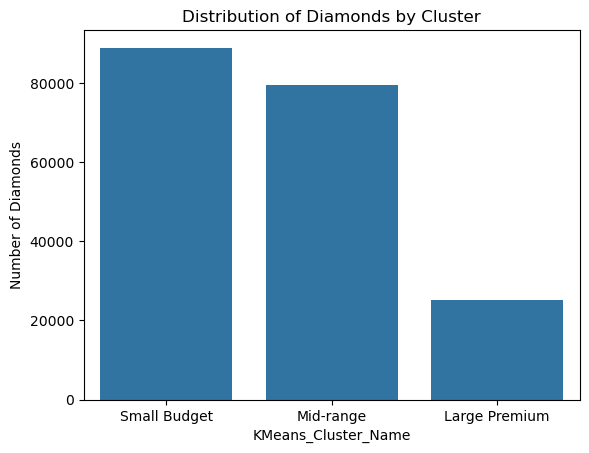

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='KMeans_Cluster_Name', data=df, order=["Small Budget","Mid-range","Large Premium"])
plt.title("Distribution of Diamonds by Cluster")
plt.ylabel("Number of Diamonds")
plt.show()

#### Price vs Carat Colored by Cluster

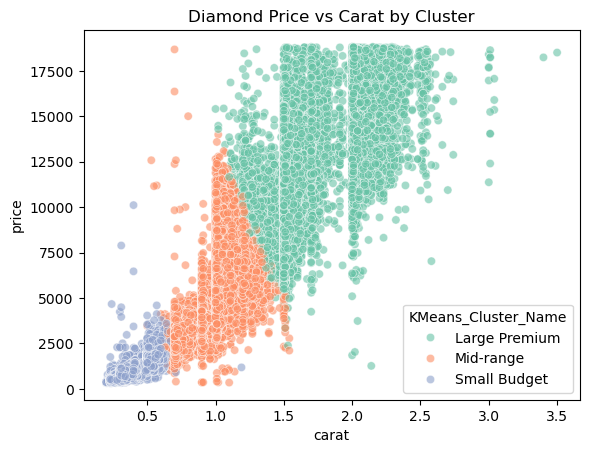

In [43]:
sns.scatterplot(x='carat', y='price', hue='KMeans_Cluster_Name', data=df, palette="Set2", alpha=0.6)
plt.title("Diamond Price vs Carat by Cluster")
plt.show()

##### Underlying Relationships

Price depends mainly on carat: the bigger the diamond, the higher the price.

Clusters reflect market segmentation:

Small Budget → affordable diamonds

Mid-range → mid-tier diamonds

Large Premium → luxury/high-value diamonds

Depth and table values are consistent → size drives clusters more than shape/quality.

Conclusion: 

We can use these clusters to target marketing or pricing strategies.

Explore other features like color or clarity within each cluster to find hidden patterns.

For presentation: scatter plots, distribution plots, and PCA 3D plots make it visually intuitive.